<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">


# Procesamiento de lenguaje natural

## Cristian Aballay A2301
## Custom embedddings con Gensim



Objetivo

El objetivo es utilizar documentos / corpus para crear embeddings de palabras basado en ese contexto. Se utilizará canciones de bandas para generar los embeddings, es decir, que los vectores tendrán la forma en función de como esa banda haya utilizado las palabras en sus canciones.

### Consigna del desafío 2

**Cada experimento realizado debe estar acompañado de una explicación o interpretación de lo observado**

Recuerden que su notebook de entrega debe poder correrse de inicio a fin sin la aparición de errores.

In [ ]:
#pip install pymupdf
#pip install spacy

   ---------------------------------------- 0.0/14.2 MB ? eta -:--:--
   -------- ------------------------------- 3.1/14.2 MB 20.7 MB/s eta 0:00:01
   ----------------- ---------------------- 6.3/14.2 MB 16.1 MB/s eta 0:00:01
   ---------------------------- ----------- 10.0/14.2 MB 16.7 MB/s eta 0:00:01
   ---------------------------------------- 14.2/14.2 MB 20.5 MB/s eta 0:00:00
   ---------------------------------------- 0.0/650.8 kB ? eta -:--:--
   --------------------------------------- 650.8/650.8 kB 32.4 MB/s eta 0:00:00
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 1.7/1.7 MB 34.6 MB/s eta 0:00:00
   ---------------------------------------- 0.0/6.2 MB ? eta -:--:--
   ---------------------------------------- 6.2/6.2 MB 59.1 MB/s eta 0:00:00

   -- -------------------------------------  1/14 [spacy-loggers]
   ----- ----------------------------------  2/14 [spacy-legacy]
   ----- --------------------------------

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import fitz
import requests
import spacy
import nltk

import multiprocessing
try:
  from gensim.models import Word2Vec
except:
  !pip install gensim
  from gensim.models import Word2Vec

from nltk.tokenize import word_tokenize

In [3]:
# Descargas iniciales necesarias
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer
from nltk.tokenize import word_tokenize, sent_tokenize

# Configuración para español
stop_words_es = set(stopwords.words('spanish'))
stemmer_es = SnowballStemmer('spanish')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\cristian.aballay\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\cristian.aballay\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\cristian.aballay\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\cristian.aballay\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\cristian.aballay\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


### Crear sus propios vectores con Gensim basado en lo visto en clase con un corpus propio (revisar enlaces sugeridos en clase 2 sobre opciones de dataset)

En vez de un artista se selecciona un libro clasico en español descargado de la pag https://www.textos.info/: 'Las mil y una noches'

In [4]:
url = 'https://www.textos.info/anonimo/las-mil-y-una-noches/epub'
response = requests.get(url)
with open('books/book.epub', 'wb') as f:
    f.write(response.content)

def read_ebook(file_path):
    doc = fitz.open(file_path)
    text_data = []
    
    for page in doc:
        text_data.append(page.get_text())
    
    # Create DataFrame from text content
    df = pd.DataFrame(text_data, columns=['text'])
    return df

df = read_ebook("./books/book.epub")
   
print("Cantidad de documentos:", df.shape[0])

MuPDF error: syntax error: css syntax error: unexpected token (OEBPS/Styles/CoverPage.css:1) (@page>,< body, div, img {  padding:...)

Cantidad de documentos: 3907


#### Preprocesamiento

Vamos a analizar algunas sentencias que existen para ver que filtro deberiamos aplicar, mientras se prueban distintos filtros con nltk 

In [5]:
from tensorflow.keras.preprocessing.text import text_to_word_sequence
print("Texto: ", df.iloc[100][0])
sentence = text_to_word_sequence(df.iloc[100][0])
print(sentence)
sentence = [w for w in sentence if w not in stop_words_es and w.isalpha()]
print(sentence)

Texto:  desapareció. Y el príncipe pudo regresar al lado de su padre, y le
dio cuenta del mal consejo del visir. Y el rey mandó matar al visir».
En seguida el visir del rey Yunán prosiguió de este modo:
«¡Y tú, oh rey, si te fías de ese médico, cuenta que te matará con la
peor de las muertes! Aunque le hayas colmado de favores y le
hayas hecho tu amigo, está preparando tu muerte. ¿Sabes por qué
te curó de tu enfermedad por el exterior de tu cuerpo, mediante una
cosa que tuviste en la mano? ¿No crees que es sencillamente para
causar tu pérdida con una segunda cosa que te mandará también
coger?» Entonces el rey Yunán dijo: «Dices la verdad. Hágase
según tu opinión, ¡oh visir bien aconsejado! Porque es muy
probable que ese médico haya venido ocultamente como un espía
para ser mi perdición. Si me ha curado con una cosa que he tenido
en la mano, muy bien podría perderme con otra que, por ejemplo,
me diera a oler». Y luego el rey Yunán dijo a su visir: «¡Oh visir!
¿qué debemos hacer con él?»

C:\Users\cristian.aballay\AppData\Local\Temp\ipykernel_17896\2104219876.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print("Texto: ", df.iloc[100][0])
C:\Users\cristian.aballay\AppData\Local\Temp\ipykernel_17896\2104219876.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  sentence = text_to_word_sequence(df.iloc[100][0])


Vemos que los filtros aplicados parecen correctos. Procedemos a aplicarlo en el dataset completo

In [6]:
sentence_tokens = []
# Recorrer todas las filas y transformar las oraciones
# en una secuencia de palabras (esto podría realizarse con NLTK o spaCy también)
for _, row in df[:None].iterrows():
    sentence = text_to_word_sequence(row[0])
    sentence = [w for w in sentence if w not in stop_words_es and w.isalpha()]
    sentence_tokens.append(sentence)

C:\Users\cristian.aballay\AppData\Local\Temp\ipykernel_17896\1465047190.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  sentence = text_to_word_sequence(row[0])


Luego entrenamos el modelo con las sentencias 'limpias'

Se modifican algunos parametros como la frecuencia minima de las palabras (5), 3 consecutivas y anteriores, 300 de dimensionalidad

In [7]:
from gensim.models.callbacks import CallbackAny2Vec
# Durante el entrenamiento gensim por defecto no informa el "loss" en cada época
# Sobrecargamos el callback para poder tener esta información
class callback(CallbackAny2Vec):
    """
    Callback to print loss after each epoch
    """
    def __init__(self):
        self.epoch = 0

    def on_epoch_end(self, model):
        loss = model.get_latest_training_loss()
        if self.epoch == 0:
            print('Loss after epoch {}: {}'.format(self.epoch, loss))
        else:
            print('Loss after epoch {}: {}'.format(self.epoch, loss- self.loss_previous_step))
        self.epoch += 1
        self.loss_previous_step = loss

In [8]:
# Crearmos el modelo generador de vectores
# En este caso utilizaremos la estructura modelo Skipgram
w2v_model = Word2Vec(min_count=5,    # frecuencia mínima de palabra para incluirla en el vocabulario
                     window=3,       # cant de palabras antes y desp de la predicha
                     vector_size=300,       # dimensionalidad de los vectores
                     negative=20,    # cantidad de negative samples... 0 es no se usa
                     workers=4,      # si tienen más cores pueden cambiar este valor
                     sg=1)           # modelo 0:CBOW  1:skipgram

In [9]:
# Obtener el vocabulario con los tokens
w2v_model.build_vocab(sentence_tokens)
# Cantidad de filas/docs encontradas en el corpus
print("Cantidad de docs en el corpus:", w2v_model.corpus_count)
# Cantidad de words encontradas en el corpus
print("Cantidad de words distintas en el corpus:", len(w2v_model.wv.index_to_key))

Cantidad de docs en el corpus: 3907
Cantidad de words distintas en el corpus: 12159


In [10]:
# Entrenamos el modelo generador de vectores
# Utilizamos nuestro callback
# Se entrenara durante 30 épocas, por el nivel de complejidad del modelo
w2v_model.train(sentence_tokens,
                 total_examples=w2v_model.corpus_count,
                 epochs=30,
                 compute_loss = True,
                 callbacks=[callback()]
                 )

Loss after epoch 0: 2062218.625
Loss after epoch 1: 1533398.625


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Loss after epoch 2: 1441525.25
Loss after epoch 3: 1375597.5
Loss after epoch 4: 1346376.0
Loss after epoch 5: 1278794.0
Loss after epoch 6: 1240846.0
Loss after epoch 7: 1217429.0


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Loss after epoch 8: 1198073.0
Loss after epoch 9: 1177004.0
Loss after epoch 10: 1158188.0
Loss after epoch 11: 1140496.0


...

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Loss after epoch 22: 931746.0


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Loss after epoch 23: 925264.0
Loss after epoch 24: 910798.0
Loss after epoch 25: 920342.0
Loss after epoch 26: 904814.0
Loss after epoch 27: 904322.0
Loss after epoch 28: 896976.0
Loss after epoch 29: 890602.0


(15482297, 17471970)

### Elegir términos de interés y buscar términos más similares y menos similares.

Empezamos viendo algunos terminos que aparecen en el modelo para elegir algunos y analizar su comportamiento frente a los mas y menos similares

In [11]:
w2v_model.wv.index_to_key

['dijo',
 'rey',
 'entonces',
 'joven',
 'noche',
 'alah',
 'si',
 'llegó',
 'tan',
 'contestó',
 'pues',
 'después',
 'aquí',
 'casa',
 'así',
 'hijo',
 'ojos',
 'dos',
 'día',
 'momento',
 'califa',
 'palabras',
 'aquel',
 'padre',
 'todas',
 'mañana',
 'tiempo',
 'cabeza',
 'vió',
 'visir',
 'palacio',
 'luego',
 'fué',
 'toda',
 'vez',
 'madre',
 'schehrazada',
 'cuanto',
 'ver',
 'hija',
 'aquella',
 'hizo',
 'mano',
 'bien',
 'oro',
 'tal',
 'corazón',
 'esposa',
 'mismo',
 'manos',
 'hacer',
 'ciudad',
 'historia',
 'vida',
 'hassán',
 'hombre',
 'señor',
 'sultán',
 'tierra',
 'puerta',
 'gran',
 'oír',
 'aparecer',
 'calló',
 'ahora',
 'hermano',
 'hacia',
 'narración',
 'preguntó',
 'alma',
 'exclamó',
 'cada',
 'puso',
 'tras',
 'ser',
 'días',
 'modo',
 'tres',
 'discretamente',
 'sólo',
 'fin',
 'princesa',
 'agua',
 'emir',
 'mil',
 'mujer',
 'jeique',
 'medio',
 'belleza',
 'alí',
 'príncipe',
 'punto',
 'saber',
 'cosa',
 'dinares',
 'vieja',
 'levantó',
 'mientras',
 '

Elegimos las palabras que parecen interesantes para buscar aquellas 4 palabras con mayor similitud y 5 con menos: 'rey', 'historias', 'china' y 'noche'

In [12]:
words = ['rey', 'historias', 'china', 'noche']
for word in words:
    print(f'* Word: {word}')
    print('Most similars:')
    print(w2v_model.wv.most_similar(positive=[word], topn=5))
    print('Less similars:')
    print(w2v_model.wv.most_similar(negative=[word], topn=5))

* Word: rey
Most similars:
[('ajam', 0.4975966215133667), ('afridonios', 0.49070271849632263), ('schahriar', 0.4801577627658844), ('samarkanda', 0.47401919960975647), ('schams', 0.46556103229522705)]
Less similars:
[('cuerdas', 0.0013830442912876606), ('cuyo', -0.012386364862322807), ('dinar', -0.013249627314507961), ('espaldilla', -0.013909898698329926), ('ganaba', -0.01729630120098591)]
* Word: historias
Most similars:
[('morales', 0.4677753448486328), ('aventuras', 0.448128342628479), ('contártela', 0.4264344573020935), ('narrar', 0.41619873046875), ('anécdotas', 0.41318479180336)]
Less similars:
[('pararon', 0.06455601751804352), ('súbito', 0.06430230289697647), ('dándole', 0.05177183076739311), ('vencido', 0.04947156459093094), ('deparado', 0.04407715052366257)]
* Word: china
Most similars:
[('sindh', 0.42026758193969727), ('schamikh', 0.3866026997566223), ('sinn', 0.38547804951667786), ('moghreb', 0.3800501227378845), ('esclarecer', 0.3786826729774475)]
Less similars:
[('fortuna'

Algunos grupos de palabras parece tener sentido su relacion ('historias' con 'aventuras', 'narrar', 'anécdotas') mientras que otras parece no estar relacionadas a pesar de su similaridad segun el modelo (como 'noche' con 'trigésimo' u 'oigas'). Pero no siempre debe haber una relacion conceptual logica, sino que dentro del relato o historia puede tener sentido en distintas sentencias y el modelo podria identificar su aparicion con el resto del grupo de palabras.

### Realizar una reduccion de dimensionalidad a los embeddings, llevándolos a 2 dimensiones. Graficar los embeddings proyectados y seleccionar una cantidad de términos (variable MAX_WORDS) de forma tal que la visualización sea adecuada.

In [13]:
from sklearn.decomposition import IncrementalPCA
from sklearn.manifold import TSNE
import numpy as np

def reduce_dimensions(model, num_dimensions = 2 ):

    vectors = np.asarray(model.wv.vectors)
    labels = np.asarray(model.wv.index_to_key)

    tsne = TSNE(n_components=num_dimensions, random_state=0)
    vectors = tsne.fit_transform(vectors)

    return vectors, labels

Elegimos 100 parablas para graficar dado el nivel alto de palabras en el modelo y para poder identificar grupos especificos.

In [101]:
# Graficar los embedddings en 2D
import plotly.graph_objects as go
import plotly.express as px

vecs, labels = reduce_dimensions(w2v_model)

MAX_WORDS=100
fig = px.scatter(x=vecs[:MAX_WORDS,0], y=vecs[:MAX_WORDS,1], text=labels[:MAX_WORDS])
fig.show()

Graficamos en 3d para tener un panorama mejor de la relacion entre las palabras

In [100]:
# Graficar los embedddings en 3D

vecs, labels = reduce_dimensions(w2v_model,3)

fig = px.scatter_3d(x=vecs[:MAX_WORDS,0], y=vecs[:MAX_WORDS,1], z=vecs[:MAX_WORDS,2],text=labels[:MAX_WORDS])
fig.update_traces(marker_size = 2)
fig.show()

### Inspeccionar el grafico y buscar pequeños grupos de palabras que puedan formarse. Interpretarlos e intentar obtener conclusiones. En lo posible, acompañar los grupos de palabras con capturas (y pegarlas en celdas de texto)

Se elige un grupo palabras del grafico en 2d que por su cercania pareciera que estan relacionadas. El grupo es: 'hermano', 'rey', 'principe', etc. Vemos que podria tener cierta relacion en cuanto a un relato en particular.

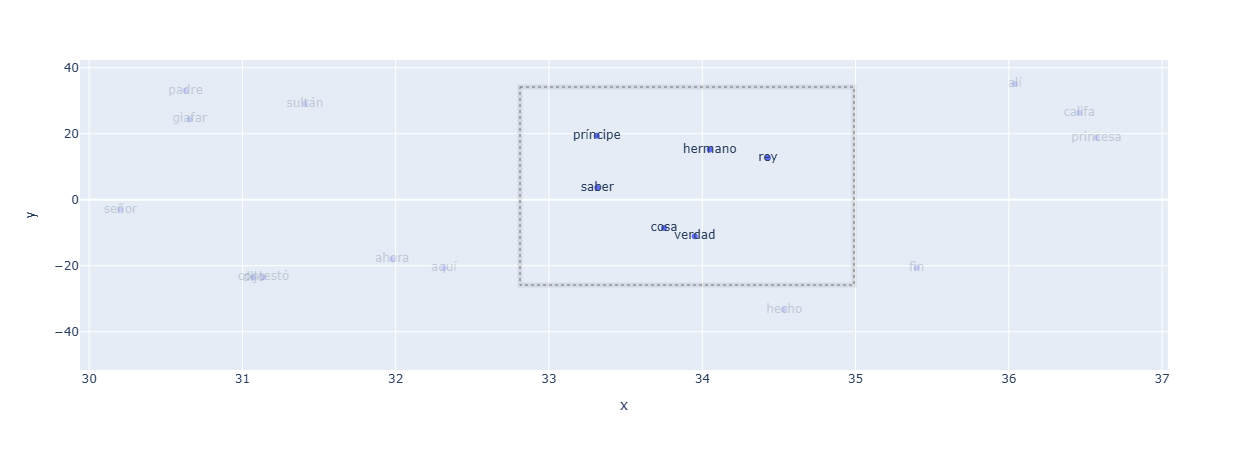

Si vemos el grafico en 3d vemos que la perspectiva cambia, no se encuentran tan cercanos como en el grafico 2d

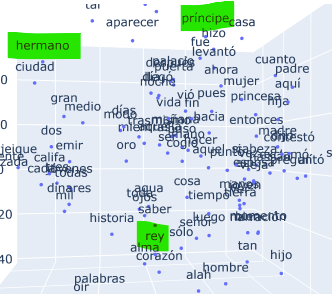

Tomamos otro grupo del grafico en 3d

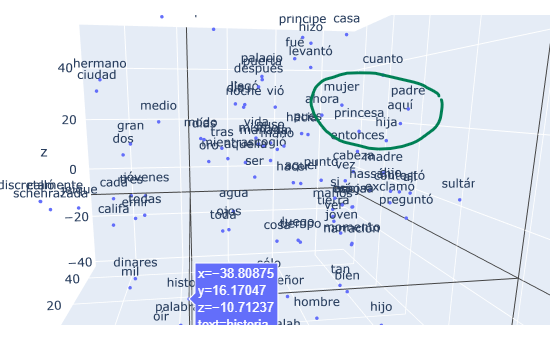

Vemos que tiene mas sentido que el grupo anterior, al menos el grupo de 'mujer', 'princesa', 'hija', 'padre'. Quizas tiene sentido porque dento de un mismo grupo de documentos (capitulos/historias similares) estos roles de personajes interactuan de alguna u otra forma. Quizas el grupo anterior de 'rey', 'hermano', 'principe' son palabras que aparecen muy seguido y el modelo los relaciona en el grafico 2d cuando se hace la reduccion de dimensionalidad de acuerdo a su importancia, pero en el 3d esta vinculadas con otras palabras.